<a href="https://colab.research.google.com/github/RamirezTovarDianaGuadalupe/ProcesosEstocasticos/blob/main/MatrizFundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

$$\Huge \color{#C5A3A3}{\text{Matriz Fundamental}}$$

Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?

$$\Large \color{#C5A3A3}{\text{1. Rata en el laberinto}}$$

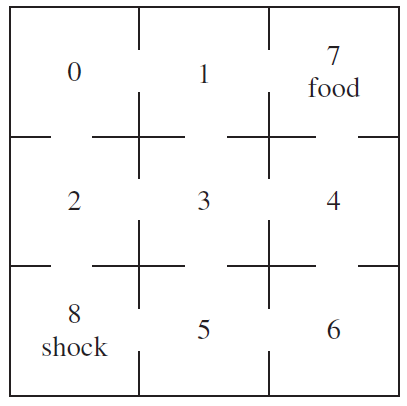

$$\color{#C5A3A3}{\text{Simulación de Monte Carlo}}$$

Para resolver el problema del laberinto, se implemento una simulación de Monte Carlo. La idea es "soltar" a la rata muchas veces en el punto inicial y observar cuántas veces logra llegar a la comida antes del shock.

Se importa la librería NumPy, que nos permite trabajar con matrices y realizar cálculos matemáticos de forma rápida.

In [28]:
import numpy as np

In [29]:
# Matriz de transición
P = np.array([
    [0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],    # 0
    [1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],  # 1
    [1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],  # 2
    [0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0], # 3
    [0, 0, 0, 1/3, 0, 0, 1/3, 1/3, 0],  # 4
    [0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],  # 5
    [0, 0, 0, 0, 1/2, 1/2, 0, 0, 0],    # 6
    [0, 0, 0, 0, 0, 0, 0, 1, 0],        # 7 (food)
    [0, 0, 0, 0, 0, 0, 0, 0, 1]         # 8 (shock)
])

Se crea la fución que se encarga de mover a la rata paso a paso por el laberinto. Se utiliza un ciclo que no se detiene hasta que la rata llega a la comida o al shock. En cada paso se usa np.random.choice para que la rata elija una salida al azar, respetando siempre las probabilidades de la matriz.

In [30]:
# 1. Función
def simular_rata(inicio, matriz):
    estado_actual = inicio
    # La rata se mueve hasta llegar a un estado absorbente (7 u 8)
    while estado_actual < 7:
        # Elige el siguiente estado basado en las probabilidades de la fila
        opciones = np.arange(9)
        probabilidades = matriz[estado_actual]
        estado_actual = np.random.choice(opciones, p=probabilidades)
    return estado_actual

Se programa el experimento para repetirse 10,000 veces. Se utiliza un contador de "éxitos" que empieza en cero y solo aumenta cuando la rata logra terminar en el estado 7 (comida).

In [31]:
# 2. Simulación 10,000 veces
intentos = 10000
exitos = 0
estado_inicial = 0

for _ in range(intentos):
    resultado = simular_rata(estado_inicial, P)
    if resultado == 7: # Si llegó a la comida
        exitos += 1

Para la probabilidad estimada se divide el número de éxitos entre el total de intentos realizados.

Esta probabilidad nos dice qué tan frecuente es que la rata gane el juego empezando desde el estado inicial.

In [32]:
# 3. Resultado simulación MC
prob_estimada = exitos / intentos

print(f"{intentos} simulaciones:")
print(f"Veces que llego a la comida: {exitos}")
print(f"Probabilidad estimada empezando en {estado_inicial}: {prob_estimada:.4f}")

10000 simulaciones:
Veces que llego a la comida: 5038
Probabilidad estimada empezando en 0: 0.5038


El resultado se aproxima al 50%, esto nos confirma que el laberinto es equilibrado para ambos destinos.

$$\color{#C5A3A3}{\text{Analítico }}$$

Para resolver el problema del laberinto, modelamos el movimiento de la rata como una Cadena de Markov de tiempo discreto.

$\color{#C5A3A3}{\text{1. Definición de variables y estados}}$

Definimos $u_i$ como la probabilidad de que el ratón, iniciando en la casilla $i$, alcance la comida (casilla 7) antes de la trampa eléctrica (casilla 8).

Estados Absorbentes: $u_7 = 1$ (Comida) y $u_8 = 0$ (Trampa).

Estados Transitorios: El ratón elige de manera uniforme entre las puertas abiertas de cada habitación.


$\color{#C5A3A3}{\text{2. Sistema de Ecuaciones de Balance}}$



Basándonos en la conectividad del laberinto, planteamos las siguientes ecuaciones:

$u_0 = \frac{1}{2} u_1 + \frac{1}{2} u_2$

$u_1 = \frac{1}{3} u_0 + \frac{1}{3} u_3 + \frac{1}{3} (1)$

$u_2 = \frac{1}{3} u_0 + \frac{1}{3} u_3 + \frac{1}{3} (0)$

$u_3 = \frac{1}{4} u_1 + \frac{1}{4} u_2 + \frac{1}{4} u_4 + \frac{1}{4} u_5$

$u_4 = \frac{1}{3} u_3 + \frac{1}{3} u_6 + \frac{1}{3} (1)$

$u_5 = \frac{1}{3} u_3 + \frac{1}{3} u_6 + \frac{1}{3} (0)$

$u_6 = \frac{1}{2} u_4 + \frac{1}{2} u_5$

$\color{#C5A3A3}{\text{3. Representación Matricial (Forma Canónica)}}$

Este sistema de ecuaciones se puede representar de forma compacta mediante la matriz de transición $P$.

En una cadena de Markov con estados absorbentes, la matriz se particiona como:

$$P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}$$

Donde $Q$ representa las transiciones entre estados transitorios y $R$ las transiciones hacia los estados absorbentes.

Submatriz $Q$ (Transitorios)

$$Q = \begin{pmatrix}
0 & 1/2 & 1/2 & 0 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 \\
1/3 & 0 & 0 & 1/3 & 0 & 0 & 0 \\
0 & 1/4 & 1/4 & 0 & 1/4 & 1/4 & 0 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 \\
0 & 0 & 0 & 1/3 & 0 & 0 & 1/3 \\
0 & 0 & 0 & 0 & 1/2 & 1/2 & 0\end{pmatrix}$$

Submatriz $R$ (Absorción hacia Comida y Trampa)

$$R = \begin{pmatrix}
0 & 0 \\
1/3 & 0 \\
0 & 1/3 \\
0 & 0 \\
1/3 & 0 \\
0 & 1/3 \\
0 & 0\end{pmatrix}$$

$\color{#C5A3A3}{\text{4. Solución mediante la Matriz Fundamental}}$

La solución al sistema de ecuaciones planteado al inicio es equivalente a calcular:

$$\mathbf{u} = (I - Q)^{-1} R$$

Matriz Fundamental ($N$): $N = (I - Q)^{-1}$.

Representa el número esperado de visitas a cada habitación.

Vector de Probabilidades ($B$): $B = N \cdot R$.

Al resolver, obtenemos que para el estado inicial $u_0$:

$$u_0 = 0.5$$

Esto confirma analíticamente que, debido a la simetría del laberinto, el ratón tiene un 50% de probabilidad de llegar a la comida partiendo desde el centro (estado 0).

In [33]:
# 1. Matrices
# Estados transitorios
transitorios = [0,1,2,3,4,5,6]

# Submatrices
Q = P[np.ix_(transitorios, transitorios)]
R = P[np.ix_(transitorios, [7])]  # Probabilidad de ir a comida

In [34]:
# 2. Resolver sistema (I-Q)p = R
I = np.eye(len(Q))
p = np.linalg.solve(I - Q, R)

In [48]:
# 3. Resultado analítico
print("Probabilidad de llegar primero a comida desde cada estado:")
for estado, prob in zip(transitorios, p):
    print(f"Estado {estado}: {prob[0]:.4f}")

print("\nProbabilidad empezando en 0:", p[0][0])

Probabilidad de llegar primero a comida desde cada estado:
Estado 0: 0.5000
Estado 1: 0.6667
Estado 2: 0.3333
Estado 3: 0.5000
Estado 4: 0.6667
Estado 5: 0.3333
Estado 6: 0.5000

Probabilidad empezando en 0: 0.49999999999999994


$$\color{#C5A3A3}{\text{Resultados}}$$

In [49]:
# Resultados
print(f"Valor Teórico (Analítico): {p[0][0]:.4f}")
print(f"Valor Simulación: {prob_estimada:.4f}")
print(f"Diferencia (Error): {abs(p[0][0] - prob_estimada):.6f}")

Valor Teórico (Analítico): 0.5000
Valor Simulación: 0.5038
Diferencia (Error): 0.003800


Los resultados obtenidos en ambos métodos coinciden. Esta mínima diferencia nos dice que la rata tiene las mismas oportunidades de ganar que de perder

$$\Large \color{#C5A3A3}{\text{2. Serpientes y escaleras}}$$

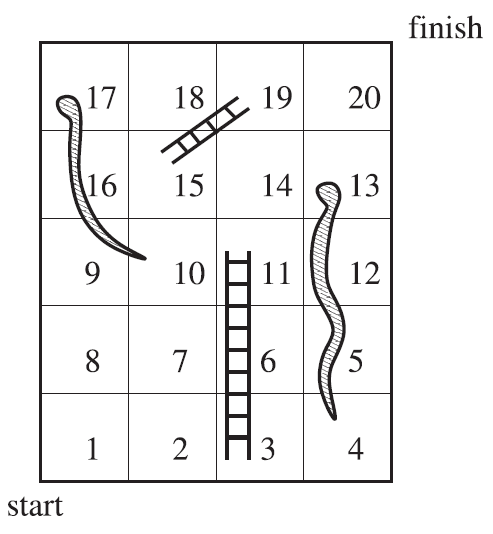

$$\color{#C5A3A3}{\text{Simulación de Monte Carlo}}$$



Se importan las librerías NumPy, para el manejo de aleatoriedad y cálculos numéricos, y Pandas, que nos facilita la organización de los datos.

In [36]:
import numpy as np
import pandas as pd

In [37]:
# Parametros para ambos métodos
n_estados = 20
meta = 20
caras_dado = 6

# Definición de celdas Escaleras/Serpientes
# Formato {inicio: fin}
shortcuts = {
    3: 11,  # Escalera
    15: 19, # Escalera
    13: 5,  # Serpiente
    17: 9   # Serpiente
}

Se crea una función encargada de simular una partida completa. Se utiliza un ciclo while que no se detiene hasta que el jugador alcanza o supera la casilla 20. En cada turno, se genera un número al azar entre 1 y 6 (el dado) y se verifica si la nueva posición tiene una serpiente o escalera utilizando un diccionario de "atajos".

In [38]:
# 1. Función
def jugar_partida():
    posicion = 1
    tiros = 0
    while posicion < meta:
        dado = np.random.randint(1, caras_dado + 1)
        tiros += 1
        nueva_pos = posicion + dado

        if nueva_pos <= meta:
            posicion = shortcuts.get(nueva_pos, nueva_pos)

    return tiros

Una vez definida la lógica, "soltamos" al jugador en el tablero 10,000 veces. Al repetir el experimento masivamente, podemos aplicar que el promedio de todos estos intentos será una estimación del valor real esperado.

In [39]:
# 2. Simulación 10,000 veces
n_simulaciones = 100000
resultados = [jugar_partida() for _ in range(n_simulaciones)]

promedio_simulacion = np.mean(resultados)

Finalmente, calculamos la media aritmética de la lista de resultados. Este número representa el promedio experimental de tiros necesarios para terminar el juego, el cual compararemos más adelante con nuestro cálculo analítico para validar que ambos coincidan.

In [40]:
# 3. Resutado Simulación MC
print("Resultados por simulación")
print(f"Número promedio de tiradas: {promedio_simulacion:.4f}")

Resultados por simulación
Número promedio de tiradas: 11.4163


$$\color{#C5A3A3}{\text{Analítico}}$$

Para resolver el problema del laberinto, se implemento una simulación de Monte Carlo. La idea es "soltar" a la rata muchas veces en el punto inicial y observar cuántas veces logra llegar a la comida antes del shock.

$\color{#C5A3A3}{\text{1. Definición de Variables}}$


Definimos $E_i$ como el número esperado de tiros adicionales necesarios para llegar a la meta, dado que el jugador se encuentra actualmente en la casilla $i$.

Estado Absorbente: $E_{20} = 0$ (Si ya estás en la meta, no necesitas más tiros).

Atajos (Reglas de la imagen): Las casillas con serpientes o escaleras se redirigen inmediatamente, por lo que su valor de esperanza es igual al de su casilla de destino:

*  $E_3 = E_{11}$ (Escalera)

*  $E_{15} = E_{19}$ (Escalera)

*  $E_{13} = E_{5}$ (Serpiente)

*  $E_{17} = E_{9}$ (Serpiente)

$\color{#C5A3A3}{\text{2. Ecuaciones de Balance}}$


Para cada casilla transitoria $i$, planteamos una ecuación que suma el tiro actual (1) más el promedio de las esperanzas de los posibles destinos tras lanzar el dado de 6 caras:

$$E_i = 1 + \frac{1}{6} \sum_{k=1}^{6} E_{\text{destino}(i+k)}$$

Ejemplos de ecuaciones según el tablero:Para la casilla 1:

$$E_1 = 1 + \frac{1}{6} (E_2 + E_{11} + E_4 + E_5 + E_6 + E_7)$$

Para la casilla 12 (antes de una serpiente):

$$E_{12} = 1 + \frac{1}{6} (E_5 + E_{14} + E_{19} + E_{16} + E_{18} + E_{19})$$

$\color{#C5A3A3}{\text{3. Representación Matricial}}$


(La Matriz Fundamental)

Resolver 19 ecuaciones simultáneas a mano es ineficiente. Por ello, trasladamos el sistema a una forma matricial compacta:

$$(I - Q) \mathbf{E} = \mathbf{1}$$

Donde:

$I$: Es la matriz identidad de $19 \times 19$.

$Q$: Es la submatriz de transición que contiene las probabilidades entre estados transitorios, integrando los saltos de las serpientes y escaleras.

$\mathbf{1}$: Es un vector columna de unos, que representa el costo de cada tirada.La solución viene dada por la Matriz Fundamental $N$:$$N = (I - Q)^{-1}$$$$\mathbf{E} = N \cdot \mathbf{1}$$El valor final que buscamos es $E_1$, que equivale a la suma de la primera fila de la matriz $N$.

$\color{#C5A3A3}{\text{4. Implementación en código}}$


Este bloque de código ejecuta el procedimiento descrito y calcula el valor exacto:

In [41]:
# 1. Crear la Matriz de Transición P (20x20)
P = np.zeros((n_estados, n_estados))

for i in range(1, n_estados):  # De la casilla 1 a la 19
    for d in range(1, caras_dado + 1):
        proxima_pos = i + d

        if proxima_pos > meta:
            destino = i # Se queda en su lugar si se pasa
        else:
            destino = shortcuts.get(proxima_pos, proxima_pos)

        P[i-1, destino-1] += 1/caras_dado

P[19, 19] = 1 # Estado absorbente

In [42]:
# 2. Matriz Q (Estados transitorios) y Matriz Fundamental N
Q = P[:19, :19]
I = np.eye(19)
N = np.linalg.inv(I - Q)

In [43]:
# 3. Resultado Analítico
# La suma de la primera fila indica el tiempo esperado partiendo del inicio
esperanza_analitica = np.sum(N[0, :])

print("Resultados analíticos")
print(f"Número promedio de tiradas (E): {esperanza_analitica:.4f}")

Resultados analíticos
Número promedio de tiradas (E): 11.4242


$$\color{#C5A3A3}{\text{Resultados}}$$

In [44]:
# Resultados
print(f"Valor Teórico (Analítico): {esperanza_analitica:.4f}")
print(f"Valor Experimental (Simulación): {promedio_simulacion:.4f}")
print(f"Diferencia (Error): {abs(esperanza_analitica - promedio_simulacion):.6f}")

Valor Teórico (Analítico): 11.4242
Valor Experimental (Simulación): 11.4163
Diferencia (Error): 0.007918


Los resultados obtenido sen ambos métodos valida la precisión del modelo matricial. La diferencia mínima de 0.0079 confirma que la simulación es correcta.